In [18]:
# ==========================================================
# Stage 1 : Environment & Global Configuration
# ==========================================================

from pathlib import Path
import os
import gc
import warnings

warnings.filterwarnings("ignore")

# ----------------------------------------------------------
# Detect Google Drive
# ----------------------------------------------------------

PROJECT_ROOT = Path("/content/drive/MyDrive/Loan_Default_Prediction")
# Checkpoint directory
CHECKPOINT_DIR = PROJECT_ROOT / "data" / "checkpoints"

print(CHECKPOINT_DIR)
print(type(CHECKPOINT_DIR))

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(
        f"\nProject directory not found:\n{PROJECT_ROOT}\n"
        "Mount Google Drive or correct the project path."
    )

# ----------------------------------------------------------
# Directory Structure
# ----------------------------------------------------------

DATA_DIR = PROJECT_ROOT / "data"

RAW_DATA_DIR = DATA_DIR / "raw"
EXTRACTED_DATA_DIR = DATA_DIR / "extracted"

CHECKPOINT_DIR = DATA_DIR / "checkpoints"
PROCESSED_DIR = DATA_DIR / "processed"

MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"

# ----------------------------------------------------------
# Create missing directories
# ----------------------------------------------------------

DIRECTORIES = [
    RAW_DATA_DIR,
    EXTRACTED_DATA_DIR,
    CHECKPOINT_DIR,
    PROCESSED_DIR,
    MODELS_DIR,
    REPORTS_DIR,
    ARTIFACTS_DIR,
    NOTEBOOK_DIR,
]

for directory in DIRECTORIES:
    directory.mkdir(parents=True, exist_ok=True)

print("=" * 60)
print("Project Root")
print(PROJECT_ROOT)

print("\nDirectory Status")
for directory in DIRECTORIES:
    print(f"✓ {directory}")

print("=" * 60)

/content/drive/MyDrive/Loan_Default_Prediction/data/checkpoints
<class 'pathlib.PosixPath'>
Project Root
/content/drive/MyDrive/Loan_Default_Prediction

Directory Status
✓ /content/drive/MyDrive/Loan_Default_Prediction/data/raw
✓ /content/drive/MyDrive/Loan_Default_Prediction/data/extracted
✓ /content/drive/MyDrive/Loan_Default_Prediction/data/checkpoints
✓ /content/drive/MyDrive/Loan_Default_Prediction/data/processed
✓ /content/drive/MyDrive/Loan_Default_Prediction/models
✓ /content/drive/MyDrive/Loan_Default_Prediction/reports
✓ /content/drive/MyDrive/Loan_Default_Prediction/artifacts
✓ /content/drive/MyDrive/Loan_Default_Prediction/notebooks


In [17]:
print(CHECKPOINT_DIR)
print(type(CHECKPOINT_DIR))

/content/drive/MyDrive/Loan_Default_Prediction/data/checkpoints
<class 'str'>


In [4]:
for file in sorted(CHECKPOINT_DIR.iterdir()):
    print(file.name)

00_raw_dataset.parquet
01_completed_loans.parquet
02_binary_target.parquet
03_feature_cleaning.parquet
04_missing_values.parquet
05_feature_engineering.parquet
06_domain_features.parquet
07_X_test.parquet
07_X_train.parquet
07_y_test.parquet
07_y_train.parquet


In [ ]:
from pathlib import Path

ROOT = Path("/content/drive/MyDrive/Loan_Default_Prediction")

if ROOT.exists():
    print(f"Project exists: {ROOT}\n")

    for path in sorted(ROOT.rglob("*")):
        if path.is_file():
            size_mb = path.stat().st_size / (1024**2)
            print(f"{size_mb:8.2f} MB  {path}")
else:
    print("Project folder does not exist.")

Project exists: /content/drive/MyDrive/Loan_Default_Prediction

  186.30 MB  /content/drive/MyDrive/Loan_Default_Prediction/data/checkpoints/00_raw_dataset.parquet
  114.85 MB  /content/drive/MyDrive/Loan_Default_Prediction/data/checkpoints/01_completed_loans.parquet
  114.98 MB  /content/drive/MyDrive/Loan_Default_Prediction/data/checkpoints/02_binary_target.parquet
   80.33 MB  /content/drive/MyDrive/Loan_Default_Prediction/data/checkpoints/03_feature_cleaning.parquet
   80.97 MB  /content/drive/MyDrive/Loan_Default_Prediction/data/checkpoints/04_missing_values.parquet
   80.96 MB  /content/drive/MyDrive/Loan_Default_Prediction/data/checkpoints/05_feature_engineering.parquet
   80.96 MB  /content/drive/MyDrive/Loan_Default_Prediction/data/checkpoints/06_domain_features.parquet
   20.32 MB  /content/drive/MyDrive/Loan_Default_Prediction/data/checkpoints/07_X_test.parquet
   69.45 MB  /content/drive/MyDrive/Loan_Default_Prediction/data/checkpoints/07_X_train.parquet
    0.03 MB  /conte

In [ ]:
# ==========================================
# Verify Dataset
# ==========================================

ACCEPTED_CSV = EXTRACTED_DATA_DIR / "accepted_2007_to_2018Q4.csv"
REJECTED_CSV = EXTRACTED_DATA_DIR / "rejected_2007_to_2018Q4.csv"

assert ACCEPTED_CSV.exists(), f"Missing: {ACCEPTED_CSV}"
assert REJECTED_CSV.exists(), f"Missing: {REJECTED_CSV}"

assert ACCEPTED_CSV.is_file()
assert REJECTED_CSV.is_file()

print("✓ Accepted CSV :", ACCEPTED_CSV)
print("✓ Rejected CSV :", REJECTED_CSV)

print(f"\nAccepted Size : {ACCEPTED_CSV.stat().st_size/(1024**3):.2f} GB")
print(f"Rejected Size : {REJECTED_CSV.stat().st_size/(1024**3):.2f} GB")

✓ Accepted CSV : /content/drive/MyDrive/Loan_Default_Prediction/data/extracted/accepted_2007_to_2018Q4.csv
✓ Rejected CSV : /content/drive/MyDrive/Loan_Default_Prediction/data/extracted/rejected_2007_to_2018Q4.csv

Accepted Size : 0.92 GB
Rejected Size : 0.88 GB


In [ ]:
# ==========================================
# Load Accepted Loan Dataset
# ==========================================

import pandas as pd
import gc
import time

start_time = time.time()

print("Loading Accepted Loan Dataset...\n")

df = pd.read_csv(
    ACCEPTED_CSV,
    low_memory=False
)

print("=" * 60)
print("Dataset Loaded Successfully")
print("=" * 60)

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

memory_gb = df.memory_usage(deep=True).sum() / (1024 ** 3)
print(f"Memory Usage : {memory_gb:.2f} GB")

print(f"\nTime Taken : {time.time() - start_time:.2f} seconds")

Loading Accepted Loan Dataset...

Dataset Loaded Successfully
Rows    : 1,361,945
Columns : 151
Memory Usage : 3.51 GB

Time Taken : 61.34 seconds


In [ ]:
# ==========================================
# Memory Optimization
# ==========================================

import numpy as np

before = df.memory_usage(deep=True).sum() / (1024**3)

print(f"Memory Before : {before:.2f} GB")

# ----------------------------
# Downcast Integer Columns
# ----------------------------

int_cols = df.select_dtypes(include=["int64"]).columns

for col in int_cols:
    df[col] = pd.to_numeric(df[col], downcast="integer")

# ----------------------------
# Downcast Float Columns
# ----------------------------

float_cols = df.select_dtypes(include=["float64"]).columns

for col in float_cols:
    df[col] = pd.to_numeric(df[col], downcast="float")

# ----------------------------
# Convert Object → Category
# Only for columns with low cardinality
# ----------------------------

object_cols = df.select_dtypes(include=["object"]).columns

for col in object_cols:

    unique_ratio = df[col].nunique(dropna=False) / len(df)

    if unique_ratio < 0.50:
        df[col] = df[col].astype("category")

gc.collect()

after = df.memory_usage(deep=True).sum() / (1024**3)

print(f"Memory After  : {after:.2f} GB")
print(f"Memory Saved  : {before-after:.2f} GB")

Memory Before : 3.51 GB
Memory After  : 0.94 GB
Memory Saved  : 2.56 GB


In [ ]:
# ==========================================
# Checkpoint 00 : Optimized Raw Dataset
# ==========================================

import os

PARQUET_PATH = CHECKPOINT_DIR / "00_raw_dataset.parquet"
PICKLE_PATH = CHECKPOINT_DIR / "00_raw_dataset.pkl"

try:
    df.to_parquet(PARQUET_PATH, index=False)

    print("✓ Checkpoint saved successfully.")
    print(f"Format : Parquet")
    print(f"Path   : {PARQUET_PATH}")

except Exception as e:

    print("Parquet save failed.")
    print("Reason:", e)
    print("\nFalling back to Pickle...\n")

    df.to_pickle(PICKLE_PATH)

    print("✓ Checkpoint saved successfully.")
    print(f"Format : Pickle")
    print(f"Path   : {PICKLE_PATH}")

✓ Checkpoint saved successfully.
Format : Parquet
Path   : /content/drive/MyDrive/Loan_Default_Prediction/data/checkpoints/00_raw_dataset.parquet


In [20]:
# ==========================================
# Checkpoint Manager
# ==========================================

import pandas as pd

def load_checkpoint(name: str):
    """
    Load a checkpoint from CHECKPOINT_DIR.

    Priority:
    1. Parquet
    2. Pickle
    """

    parquet_file = CHECKPOINT_DIR / f"{name}.parquet"
    pickle_file = CHECKPOINT_DIR / f"{name}.pkl"

    if parquet_file.exists():
        print(f"✓ Loaded: {parquet_file.name}")
        return pd.read_parquet(parquet_file)

    if pickle_file.exists():
        print(f"✓ Loaded: {pickle_file.name}")
        return pd.read_pickle(pickle_file)

    raise FileNotFoundError(
        f"Checkpoint '{name}' not found."
    )


def save_checkpoint(df, name: str):
    """
    Save checkpoint.
    Tries Parquet first, falls back to Pickle.
    """

    parquet_file = CHECKPOINT_DIR / f"{name}.parquet"
    pickle_file = CHECKPOINT_DIR / f"{name}.pkl"

    try:
        df.to_parquet(parquet_file, index=False)
        print(f"✓ Saved: {parquet_file.name}")

    except Exception:
        df.to_pickle(pickle_file)
        print(f"✓ Saved: {pickle_file.name}")

In [21]:
# ==========================================
# Stage 01 : Completed Loans
# ==========================================

df = load_checkpoint("00_raw_dataset")

print("Original Shape :", df.shape)
print()

print("Loan Status Distribution")
print("-" * 40)
print(df["loan_status"].value_counts(dropna=False))
print()

# ------------------------------------------
# Keep only completed loans
# ------------------------------------------

COMPLETED_STATUSES = [
    "Fully Paid",
    "Charged Off"
]

df = df[df["loan_status"].isin(COMPLETED_STATUSES)]

df.reset_index(drop=True, inplace=True)

print("Shape After Filtering :", df.shape)
print()

print("Remaining Loan Status")
print("-" * 40)
print(df["loan_status"].value_counts())

save_checkpoint(df, "01_completed_loans")

✓ Loaded: 00_raw_dataset.parquet
Original Shape : (1361945, 151)

Loan Status Distribution
----------------------------------------
loan_status
Fully Paid            712787
Current               448330
Charged Off           182185
Late (31-120 days)     11738
In Grace Period         4608
Late (16-30 days)       2258
Default                   22
NaN                       17
Name: count, dtype: int64

Shape After Filtering : (894972, 151)

Remaining Loan Status
----------------------------------------
loan_status
Fully Paid            712787
Charged Off           182185
Current                    0
Default                    0
In Grace Period            0
Late (16-30 days)          0
Late (31-120 days)         0
Name: count, dtype: int64
✓ Saved: 01_completed_loans.parquet


In [ ]:
# ==========================================
# Stage 02 : Binary Target
# ==========================================

df = load_checkpoint("01_completed_loans")

print("Loan Status Before Encoding")
print("-" * 40)
print(df["loan_status"].value_counts())
print()

# ------------------------------------------
# Create Binary Target
# ------------------------------------------

TARGET_MAPPING = {
    "Fully Paid": 0,
    "Charged Off": 1
}

df["target"] = df["loan_status"].map(TARGET_MAPPING).astype("int8")

print("Target Distribution")
print("-" * 40)
print(df["target"].value_counts())
print()

print("Target Ratio (%)")
print("-" * 40)
print(
    (df["target"]
     .value_counts(normalize=True)
     .mul(100)
     .round(2))
)

save_checkpoint(df, "02_binary_target")

✓ Loaded: 01_completed_loans.parquet
Loan Status Before Encoding
----------------------------------------
loan_status
Fully Paid            712787
Charged Off           182185
Current                    0
Default                    0
In Grace Period            0
Late (16-30 days)          0
Late (31-120 days)         0
Name: count, dtype: int64

Target Distribution
----------------------------------------
target
0    712787
1    182185
Name: count, dtype: int64

Target Ratio (%)
----------------------------------------
target
0    79.64
1    20.36
Name: proportion, dtype: float64
✓ Saved: 02_binary_target.parquet


In [ ]:
# ==========================================
# Stage 03 : Feature Audit
# ==========================================

df = load_checkpoint("02_binary_target")

feature_audit = pd.DataFrame({
    "feature": df.columns,
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isnull().sum(),
    "missing_percent": (df.isnull().mean() * 100).round(2),
    "unique_values": df.nunique(dropna=False),
    "memory_mb": (
        df.memory_usage(deep=True)
          .iloc[1:]          # Remove Index memory
          .div(1024**2)
          .round(2)
          .values
    )
})

feature_audit = (
    feature_audit
    .sort_values("missing_percent", ascending=False)
    .reset_index(drop=True)
)

display(feature_audit.head(20))

# ==========================================
# Save Feature Audit Report
# ==========================================

from pathlib import Path

REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

audit_path = REPORTS_DIR / "feature_audit.csv"

feature_audit.to_csv(audit_path, index=False)

print(f"\n✓ Feature audit saved to:\n{audit_path}")

✓ Loaded: 02_binary_target.parquet


,feature,dtype,missing_count,missing_percent,unique_values,memory_mb
0,member_id,float32,894972,100.00,1,3.41
1,next_pymnt_d,category,894972,100.00,1,0.85
2,orig_projected_additional_accrued_interest,float32,892216,99.69,2603,3.41
3,sec_app_mths_since_last_major_derog,float32,891035,99.56,106,3.41
4,hardship_length,float32,890903,99.55,2,3.41
5,hardship_amount,float32,890903,99.55,3758,3.41
6,hardship_status,category,890903,99.55,3,0.85
7,deferral_term,float32,890903,99.55,2,3.41
8,hardship_end_date,category,890903,99.55,26,0.86
9,hardship_reason,category,890903,99.55,10,0.85



✓ Feature audit saved to:
/content/drive/MyDrive/Loan_Default_Prediction/reports/feature_audit.csv


In [22]:
# ==========================================
# Stage 04 : Feature Classification
# ==========================================

df = load_checkpoint("02_binary_target")

# --------------------------------------------------
# Constant Features
# --------------------------------------------------

constant_features = [
    col for col in df.columns
    if df[col].nunique(dropna=False) <= 1
]

# --------------------------------------------------
# High Missing Features (>90%)
# --------------------------------------------------

high_missing_features = (
    df.isnull()
      .mean()
      .loc[lambda x: x > 0.90]
      .index
      .tolist()
)

# --------------------------------------------------
# Identifier Features
# --------------------------------------------------

identifier_features = [
    "id",
    "member_id"
]

identifier_features = [
    col for col in identifier_features
    if col in df.columns
]

# --------------------------------------------------
# Leakage Features
# --------------------------------------------------

leakage_candidates = [
    "loan_status",
    "collection_recovery_fee",
    "recoveries",
    "total_rec_prncp",
    "total_rec_int",
    "total_rec_late_fee",
    "last_pymnt_d",
    "last_pymnt_amnt",
    "next_pymnt_d",
    "last_credit_pull_d",
    "out_prncp",
    "out_prncp_inv",
    "total_pymnt",
    "total_pymnt_inv"
]

leakage_features = [
    col for col in leakage_candidates
    if col in df.columns
]

# --------------------------------------------------
# Summary
# --------------------------------------------------

print(f"Constant Features      : {len(constant_features)}")
print(f"High Missing Features  : {len(high_missing_features)}")
print(f"Identifier Features    : {len(identifier_features)}")
print(f"Leakage Features       : {len(leakage_features)}")

✓ Loaded: 02_binary_target.parquet
Constant Features      : 7
High Missing Features  : 39
Identifier Features    : 2
Leakage Features       : 14


In [23]:
# ==========================================
# Stage 05 : Remove Unnecessary Features
# ==========================================

df = load_checkpoint("02_binary_target")

# ------------------------------------------
# High Cardinality Features
# ------------------------------------------

high_cardinality_features = [
    "url",
    "emp_title",
    "title",
    "zip_code"
]

# ------------------------------------------
# Combine all features to drop
# ------------------------------------------

columns_to_drop = (
    leakage_features
    + high_missing_features
    + constant_features
    + identifier_features
    + high_cardinality_features
)

# Remove duplicates while preserving order
columns_to_drop = list(dict.fromkeys(columns_to_drop))

print(f"Features to Remove : {len(columns_to_drop)}")

# ------------------------------------------
# Drop Features
# ------------------------------------------

df.drop(columns=columns_to_drop, inplace=True, errors="ignore")

print(f"Remaining Features : {df.shape[1]}")

# ------------------------------------------
# Save Checkpoint
# ------------------------------------------

save_checkpoint(df, "03_feature_cleaning")

print("✓ Feature cleaning completed successfully.")

✓ Loaded: 02_binary_target.parquet
Features to Remove : 60
Remaining Features : 92
✓ Saved: 03_feature_cleaning.parquet
✓ Feature cleaning completed successfully.


In [ ]:
# ==========================================
# Stage 06 : Missing Value Analysis
# ==========================================

df = load_checkpoint("03_feature_cleaning")

missing_summary = (
    df.isnull()
      .sum()
      .to_frame("missing_count")
)

missing_summary["missing_percent"] = (
    missing_summary["missing_count"] / len(df) * 100
).round(2)

missing_summary = (
    missing_summary
    .query("missing_count > 0")
    .sort_values("missing_percent", ascending=False)
)

display(missing_summary)

missing_summary.to_csv(
    REPORTS_DIR / "missing_value_report.csv"
)

print("=" * 50)
print(f"Features with Missing Values : {len(missing_summary)}")
print("=" * 50)

✓ Loaded: 03_feature_cleaning.parquet


,missing_count,missing_percent
mths_since_last_record,731197,81.70
mths_since_recent_bc_dlq,666356,74.46
mths_since_last_major_derog,636959,71.17
il_util,622571,69.56
mths_since_rcnt_il,588278,65.73
open_rv_24m,579755,64.78
open_rv_12m,579755,64.78
inq_last_12m,579756,64.78
open_il_12m,579755,64.78
open_acc_6m,579756,64.78


Features with Missing Values : 35


# **Imputation Strategy**

In [ ]:
# ==========================================
# Stage 07 : Build Imputation Strategy
# ==========================================

df = load_checkpoint("03_feature_cleaning")

# ------------------------------------------
# Separate Numerical & Categorical Columns
# ------------------------------------------

numerical_columns = (
    df.select_dtypes(include=["number"])
      .columns
      .tolist()
)

categorical_columns = (
    df.select_dtypes(exclude=["number"])
      .columns
      .tolist()
)

# Remove Target
if "target" in numerical_columns:
    numerical_columns.remove("target")

# ------------------------------------------
# Build Imputation Strategy
# ------------------------------------------

imputation_strategy = {}

for col in numerical_columns:
    if df[col].isna().sum() > 0:
        imputation_strategy[col] = "median"

for col in categorical_columns:
    if df[col].isna().sum() > 0:
        imputation_strategy[col] = "mode"

# ------------------------------------------
# Review Strategy
# ------------------------------------------

strategy_df = (
    pd.DataFrame.from_dict(
        imputation_strategy,
        orient="index",
        columns=["strategy"]
    )
    .reset_index()
    .rename(columns={"index": "feature"})
)

display(strategy_df)

strategy_df.to_csv(
    REPORTS_DIR / "imputation_strategy.csv",
    index=False
)

print("=" * 50)
print(f"Features to Impute : {len(strategy_df)}")
print("=" * 50)

✓ Loaded: 03_feature_cleaning.parquet


,feature,strategy
0,dti,median
1,inq_last_6mths,median
2,mths_since_last_delinq,median
3,mths_since_last_record,median
4,revol_util,median
5,mths_since_last_major_derog,median
6,open_acc_6m,median
7,open_act_il,median
8,open_il_12m,median
9,open_il_24m,median


Features to Impute : 35


In [ ]:
# ==========================================
# Stage 08 : Missing Value Imputation
# ==========================================

df = load_checkpoint("03_feature_cleaning")

# ------------------------------------------
# Numerical Features -> Median
# ------------------------------------------

numerical_columns = df.select_dtypes(include=["number"]).columns.tolist()

if "target" in numerical_columns:
    numerical_columns.remove("target")

for col in numerical_columns:

    if df[col].isna().any():

        median_value = df[col].median()

        df[col].fillna(median_value, inplace=True)

# ------------------------------------------
# Categorical Features -> Mode
# ------------------------------------------

categorical_columns = df.select_dtypes(exclude=["number"]).columns.tolist()

for col in categorical_columns:

    if df[col].isna().any():

        mode_value = df[col].mode(dropna=True)

        if not mode_value.empty:
            df[col].fillna(mode_value.iloc[0], inplace=True)

# ------------------------------------------
# Verification
# ------------------------------------------

remaining_missing = df.isnull().sum().sum()

print(f"Remaining Missing Values : {remaining_missing:,}")

assert remaining_missing == 0, "Missing values still exist."

# ------------------------------------------
# Save Checkpoint
# ------------------------------------------

save_checkpoint(df, "04_missing_values")

✓ Loaded: 03_feature_cleaning.parquet
Remaining Missing Values : 0
✓ Saved: 04_missing_values.parquet


In [ ]:
# ==========================================
# Stage 09 : Date Feature Engineering
# ==========================================

df = load_checkpoint("04_missing_values")

date_columns = ["issue_d", "earliest_cr_line"]

# ------------------------------------------
# Convert to datetime safely
# ------------------------------------------

for col in date_columns:

    if col not in df.columns:
        continue

    # Handle category dtype
    if pd.api.types.is_categorical_dtype(df[col]):
        df[col] = df[col].astype(str)

    df[col] = pd.to_datetime(
        df[col],
        format="%b-%Y",
        errors="coerce"
    )

# ------------------------------------------
# Reference Date
# ------------------------------------------

reference_date = df["issue_d"].dropna().max()

# ------------------------------------------
# Credit History
# ------------------------------------------

if "earliest_cr_line" in df.columns:

    df["credit_history_years"] = (
        (reference_date - df["earliest_cr_line"])
        .dt.days.div(365.25)
        .round(2)
    )

# ------------------------------------------
# Loan Issue Features
# ------------------------------------------

df["issue_year"] = df["issue_d"].dt.year.astype("Int16")
df["issue_month"] = df["issue_d"].dt.month.astype("Int8")

# ------------------------------------------
# Remove Original Date Columns
# ------------------------------------------

df.drop(
    columns=date_columns,
    inplace=True,
    errors="ignore"
)

print("✓ Date feature engineering completed.")

save_checkpoint(df, "05_feature_engineering")

✓ Loaded: 04_missing_values.parquet
✓ Date feature engineering completed.
✓ Saved: 05_feature_engineering.parquet


In [ ]:
# ==========================================
# Stage 10 : Domain Feature Engineering
# ==========================================

import numpy as np
import pandas as pd

df = load_checkpoint("05_feature_engineering")

# --------------------------------------------------
# emp_length
# --------------------------------------------------

if "emp_length" in df.columns:

    emp = (
        df["emp_length"]
        .astype(str)
        .str.strip()
        .replace({
            "< 1 year": "0",
            "10+ years": "10",
            "n/a": np.nan,
            "nan": np.nan
        })
        .str.replace(" years", "", regex=False)
        .str.replace(" year", "", regex=False)
    )

    df["emp_length"] = pd.to_numeric(
        emp,
        errors="coerce"
    ).astype("float32")

# --------------------------------------------------
# term
# --------------------------------------------------

if "term" in df.columns:

    df["term"] = (
        df["term"]
        .astype(str)
        .str.extract(r"(\d+)", expand=False)
        .astype("int16")
    )

# --------------------------------------------------
# grade
# --------------------------------------------------

if "grade" in df.columns:

    grade_mapping = {
        "A":1,
        "B":2,
        "C":3,
        "D":4,
        "E":5,
        "F":6,
        "G":7
    }

    df["grade"] = (
        df["grade"]
        .map(grade_mapping)
        .astype("int8")
    )

# --------------------------------------------------
# sub_grade
# --------------------------------------------------

if "sub_grade" in df.columns:

    subgrade_mapping = {}

    for i, letter in enumerate("ABCDEFG", start=1):
        for number in range(1, 6):
            subgrade_mapping[f"{letter}{number}"] = i * 10 + number

    df["sub_grade"] = (
        df["sub_grade"]
        .map(subgrade_mapping)
        .astype("int8")
    )

print("\nFeature Engineering Summary")
print("-" * 40)

for feature in ["emp_length", "term", "grade", "sub_grade"]:
    if feature in df.columns:
        print(f"{feature:<15} : {df[feature].dtype}")

save_checkpoint(df, "06_domain_features")

✓ Loaded: 05_feature_engineering.parquet

Feature Engineering Summary
----------------------------------------
emp_length      : float32
term            : int16
grade           : int8
sub_grade       : int8
✓ Saved: 06_domain_features.parquet


In [ ]:
# Raw Data
#       ↓
# Cleaning
#       ↓
# Feature Engineering
#       ↓
# Train/Test Split
#       ↓
# Fit Encoder ONLY on X_train
#       ↓
# Transform X_train
#       ↓
# Transform X_test
#       ↓
# Train Model

In [6]:
# ==========================================
# Stage 11 : Train-Test Split
# ==========================================

from sklearn.model_selection import train_test_split

df = load_checkpoint("06_domain_features")

# ------------------------------------------
# Features & Target
# ------------------------------------------

X = df.drop(columns=["target"])
y = df["target"]

# ------------------------------------------
# Stratified Split
# ------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Train Shape : {X_train.shape}")
print(f"Test Shape  : {X_test.shape}")

print("\nTarget Distribution")

print("\nTrain")
print(y_train.value_counts(normalize=True).round(4))

print("\nTest")
print(y_test.value_counts(normalize=True).round(4))

# ------------------------------------------
# Save Checkpoints
# ------------------------------------------

save_checkpoint(X_train, "07_X_train")
save_checkpoint(X_test, "07_X_test")
save_checkpoint(y_train.to_frame(), "07_y_train")
save_checkpoint(y_test.to_frame(), "07_y_test")

✓ Loaded: 06_domain_features.parquet
Train Shape : (715977, 96)
Test Shape  : (178995, 96)

Target Distribution

Train
target
0    0.7964
1    0.2036
Name: proportion, dtype: float64

Test
target
0    0.7964
1    0.2036
Name: proportion, dtype: float64
✓ Saved: 07_X_train.parquet
✓ Saved: 07_X_test.parquet
✓ Saved: 07_y_train.parquet
✓ Saved: 07_y_test.parquet


In [39]:
# ==========================================
# Stage 12c : Preprocessing Pipeline (Leak-Free Data)
# ==========================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

X_train_final = load_checkpoint("07c_X_train_final")
X_test_final = load_checkpoint("07c_X_test_final")

numerical_features = X_train_final.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train_final.select_dtypes(exclude=["number"]).columns.tolist()

print(f"Numerical Features   : {len(numerical_features)}")
print(f"Categorical Features : {len(categorical_features)}")

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

print("Pipeline created successfully.")

✓ Loaded: 07c_X_train_final.parquet
✓ Loaded: 07c_X_test_final.parquet
Numerical Features   : 84
Categorical Features : 6
Pipeline created successfully.


In [40]:
# ==========================================
# Stage 13c : Fit Preprocessor (Leak-Free Data)
# ==========================================

import gc
import numpy as np
from scipy import sparse
import joblib

print("Fitting preprocessor...")

X_train_processed = preprocessor.fit_transform(X_train_final)

print("Transforming test data...")

X_test_processed = preprocessor.transform(X_test_final)

print("Done.")

# ------------------------------------------
# Save (handles both sparse and dense output)
# ------------------------------------------

def save_processed(matrix, path_no_ext):
    if sparse.issparse(matrix):
        sparse.save_npz(f"{path_no_ext}.npz", matrix)
        print(f"✓ Saved sparse : {path_no_ext}.npz")
    else:
        np.save(f"{path_no_ext}.npy", matrix)
        print(f"✓ Saved dense  : {path_no_ext}.npy")

save_processed(X_train_processed, f"{CHECKPOINT_DIR}/08c_X_train_processed")
save_processed(X_test_processed, f"{CHECKPOINT_DIR}/08c_X_test_processed")

joblib.dump(
    preprocessor,
    f"{CHECKPOINT_DIR}/preprocessor_final.joblib"
)

# ------------------------------------------
# Free RAM
# ------------------------------------------

del X_train_final
del X_test_final

gc.collect()

print("=" * 50)
print("Preprocessor fitted successfully.")
print(f"Train Shape : {X_train_processed.shape}")
print(f"Test Shape  : {X_test_processed.shape}")
print(f"Is sparse   : {sparse.issparse(X_train_processed)}")
print("=" * 50)

Fitting preprocessor...
Transforming test data...
Done.
✓ Saved dense  : /content/drive/MyDrive/Loan_Default_Prediction/data/checkpoints/08c_X_train_processed.npy
✓ Saved dense  : /content/drive/MyDrive/Loan_Default_Prediction/data/checkpoints/08c_X_test_processed.npy
Preprocessor fitted successfully.
Train Shape : (715977, 111)
Test Shape  : (178995, 111)
Is sparse   : False


In [41]:
# ==========================================
# Stage 14c : Baseline Model (Leak-Free Data)
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

y_train = load_checkpoint("07_y_train").squeeze()
y_test = load_checkpoint("07_y_test").squeeze()

baseline_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

baseline_model.fit(
    X_train_processed,
    y_train
)

print("✓ Logistic Regression trained successfully.")

# ------------------------------------------
# Evaluate
# ------------------------------------------

y_train_proba = baseline_model.predict_proba(X_train_processed)[:, 1]
y_test_proba = baseline_model.predict_proba(X_test_processed)[:, 1]

train_auc = roc_auc_score(y_train, y_train_proba)
test_auc = roc_auc_score(y_test, y_test_proba)

train_pr_auc = average_precision_score(y_train, y_train_proba)
test_pr_auc = average_precision_score(y_test, y_test_proba)

print(f"\nTrain ROC-AUC : {train_auc:.4f}")
print(f"Test ROC-AUC  : {test_auc:.4f}")
print(f"Train PR-AUC  : {train_pr_auc:.4f}")
print(f"Test PR-AUC   : {test_pr_auc:.4f}")

✓ Loaded: 07_y_train.parquet
✓ Loaded: 07_y_test.parquet
✓ Logistic Regression trained successfully.

Train ROC-AUC : 0.7276
Test ROC-AUC  : 0.7262
Train PR-AUC  : 0.4012
Test PR-AUC   : 0.3999


In [27]:
# ==========================================
# Fix: Remove High-Cardinality / Low-Value Categorical Columns (Corrected)
# ==========================================

X_train_fixed = load_checkpoint("07_X_train").copy()
X_test_fixed = load_checkpoint("07_X_test").copy()

drop_cols = ["url", "emp_title", "title"]

X_train_fixed.drop(columns=drop_cols, inplace=True)
X_test_fixed.drop(columns=drop_cols, inplace=True)

for col in ["zip_code", "addr_state"]:
    freq_map = X_train_fixed[col].value_counts(normalize=True)

    # Cast to float BEFORE fillna, so it's a plain numeric column, not Categorical
    X_train_fixed[f"{col}_freq"] = (
        X_train_fixed[col].map(freq_map).astype("float32")
    )
    X_test_fixed[f"{col}_freq"] = (
        X_test_fixed[col].map(freq_map).astype("float32").fillna(0.0)
    )

X_train_fixed.drop(columns=["zip_code", "addr_state"], inplace=True)
X_test_fixed.drop(columns=["zip_code", "addr_state"], inplace=True)

print(f"X_train_fixed shape : {X_train_fixed.shape}")
print(f"X_test_fixed shape  : {X_test_fixed.shape}")

save_checkpoint(X_train_fixed, "07b_X_train_fixed")
save_checkpoint(X_test_fixed, "07b_X_test_fixed")

✓ Loaded: 07_X_train.parquet
✓ Loaded: 07_X_test.parquet
X_train_fixed shape : (715977, 93)
X_test_fixed shape  : (178995, 93)
✓ Saved: 07b_X_train_fixed.parquet
✓ Saved: 07b_X_test_fixed.parquet


In [42]:
# ==========================================
# Stage 15c : Validation Split (Leak-Free Data)
# ==========================================

from sklearn.model_selection import train_test_split

train_idx, val_idx = train_test_split(
    range(X_train_processed.shape[0]),
    test_size=0.15,
    random_state=42,
    stratify=y_train
)

X_tr = X_train_processed[train_idx]
X_val = X_train_processed[val_idx]

y_tr = y_train.iloc[train_idx]
y_val = y_train.iloc[val_idx]

print(f"X_tr shape  : {X_tr.shape}")
print(f"X_val shape : {X_val.shape}")
print(f"X_test shape: {X_test_processed.shape} (untouched, still fully held out)")

X_tr shape  : (608580, 111)
X_val shape : (107397, 111)
X_test shape: (178995, 111) (untouched, still fully held out)


In [44]:
# ==========================================
# Stage 16c-v2 : LightGBM Model (Regularized)
# ==========================================

import lightgbm as lgb
from sklearn.metrics import roc_auc_score, average_precision_score

scale_pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()

lgb_model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.02,
    num_leaves=15,            # much simpler trees
    max_depth=5,               # cap depth explicitly
    min_child_samples=200,     # require more samples per leaf, resists noise
    subsample=0.8,             # row sampling (bagging)
    subsample_freq=1,
    colsample_bytree=0.8,      # feature sampling per tree
    reg_alpha=1.0,              # L1 regularization
    reg_lambda=1.0,             # L2 regularization
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
)

lgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(50)],
)

y_tr_proba = lgb_model.predict_proba(X_tr)[:, 1]
y_val_proba = lgb_model.predict_proba(X_val)[:, 1]
y_test_proba_lgb = lgb_model.predict_proba(X_test_processed)[:, 1]

print(f"\nTrain ROC-AUC      : {roc_auc_score(y_tr, y_tr_proba):.4f}")
print(f"Validation ROC-AUC : {roc_auc_score(y_val, y_val_proba):.4f}")
print(f"Test ROC-AUC       : {roc_auc_score(y_test, y_test_proba_lgb):.4f}")

print(f"\nTrain PR-AUC       : {average_precision_score(y_tr, y_tr_proba):.4f}")
print(f"Validation PR-AUC  : {average_precision_score(y_val, y_val_proba):.4f}")
print(f"Test PR-AUC        : {average_precision_score(y_test, y_test_proba_lgb):.4f}")

[LightGBM] [Info] Number of positive: 123886, number of negative: 484694
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.323644 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9808
[LightGBM] [Info] Number of data points in the train set: 608580, number of used features: 108
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203566 -> initscore=-1.364156
[LightGBM] [Info] Start training from score -1.364156
Training until validation scores don't improve for 50 rounds
[50]	valid_0's auc: 0.718184	valid_0's binary_logloss: 0.530009
Early stopping, best iteration is:
[11]	valid_0's auc: 0.712653	valid_0's binary_logloss: 0.493044

Train ROC-AUC      : 0.7131
Validation ROC-AUC : 0.7127
Test ROC-AUC       : 0.7114

Train PR-AUC       : 0.3776
Validation PR-AUC  : 0.3766
Test PR-AUC        : 0.3768


In [36]:
# ==========================================
# Stage 17 : Feature Importance (LightGBM)
# ==========================================

import pandas as pd

# Get feature names from the preprocessor (numeric names + expanded one-hot names)
feature_names = preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": lgb_model.feature_importances_
}).sort_values("Importance", ascending=False)

print(f"Total Features : {len(feature_importance)}")
display(feature_importance.head(20))

Total Features : 115


,Feature,Importance
22,num__last_fico_range_high,507
82,num__issue_year,280
113,cat__debt_settlement_flag_N,240
5,num__installment,214
3,num__term,192
9,num__annual_inc,189
10,num__dti,157
51,num__mo_sin_old_rev_tl_op,135
81,num__credit_history_years,131
12,num__fico_range_low,120


In [37]:
# ==========================================
# Diagnostic: Check for Remaining Post-Origination Fields
# ==========================================

X_check = load_checkpoint("07b_X_train_fixed")

suspicious_keywords = ["last_", "settlement", "hardship", "recover", "collection", "pymnt", "rec_"]

suspicious_cols = [
    col for col in X_check.columns
    if any(kw in col.lower() for kw in suspicious_keywords)
]

print("Potentially leaky columns still present:")
for col in suspicious_cols:
    print(" -", col)

✓ Loaded: 07b_X_train_fixed.parquet
Potentially leaky columns still present:
 - inq_last_6mths
 - mths_since_last_delinq
 - mths_since_last_record
 - last_fico_range_high
 - last_fico_range_low
 - collections_12_mths_ex_med
 - mths_since_last_major_derog
 - inq_last_12m
 - pub_rec_bankruptcies
 - debt_settlement_flag


In [38]:
# ==========================================
# Stage 18 : Remove Confirmed Leakage Features & Rebuild
# ==========================================

X_train_final = load_checkpoint("07b_X_train_fixed").copy()
X_test_final = load_checkpoint("07b_X_test_fixed").copy()

leaky_cols = ["last_fico_range_high", "last_fico_range_low", "debt_settlement_flag"]

X_train_final.drop(columns=leaky_cols, inplace=True)
X_test_final.drop(columns=leaky_cols, inplace=True)

print(f"X_train_final shape : {X_train_final.shape}")
print(f"X_test_final shape  : {X_test_final.shape}")

save_checkpoint(X_train_final, "07c_X_train_final")
save_checkpoint(X_test_final, "07c_X_test_final")

✓ Loaded: 07b_X_train_fixed.parquet
✓ Loaded: 07b_X_test_fixed.parquet
X_train_final shape : (715977, 90)
X_test_final shape  : (178995, 90)
✓ Saved: 07c_X_train_final.parquet
✓ Saved: 07c_X_test_final.parquet


Classification Report (threshold = 0.5)
              precision    recall  f1-score   support

  No Default       0.88      0.67      0.76    142558
     Default       0.34      0.66      0.45     36437

    accuracy                           0.67    178995
   macro avg       0.61      0.66      0.61    178995
weighted avg       0.77      0.67      0.70    178995



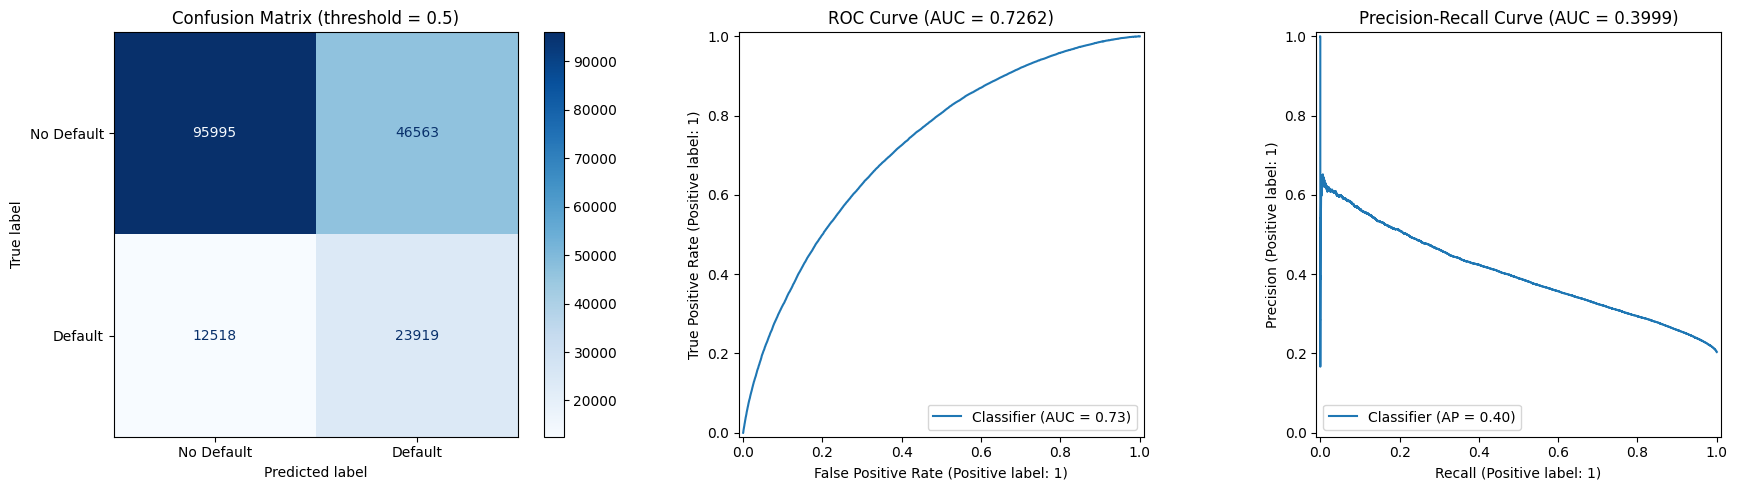

In [47]:
# ==========================================
# Stage 19 : Final Evaluation — Confusion Matrix & Classification Report
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)

# Recompute predictions cleanly using the final baseline model
y_test_pred = (y_test_proba >= 0.5).astype(int)

print("Classification Report (threshold = 0.5)")
print("=" * 55)
print(classification_report(y_test, y_test_pred, target_names=["No Default", "Default"]))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred, display_labels=["No Default", "Default"],
    cmap="Blues", ax=axes[0]
)
axes[0].set_title("Confusion Matrix (threshold = 0.5)")

RocCurveDisplay.from_predictions(y_test, y_test_proba, ax=axes[1])
axes[1].set_title(f"ROC Curve (AUC = {test_auc:.4f})")

PrecisionRecallDisplay.from_predictions(y_test, y_test_proba, ax=axes[2])
axes[2].set_title(f"Precision-Recall Curve (AUC = {test_pr_auc:.4f})")

plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/final_evaluation_plots.png", dpi=150)
plt.show()

In [48]:
# ==========================================
# Stage 20 : Threshold Tuning
# ==========================================

import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.05, 0.95, 0.05)
results = []

for t in thresholds:
    preds = (y_test_proba >= t).astype(int)
    results.append({
        "threshold": round(t, 2),
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
        "f1": f1_score(y_test, preds, zero_division=0),
    })

threshold_df = pd.DataFrame(results)

best_f1_row = threshold_df.loc[threshold_df["f1"].idxmax()]

print("Threshold sweep:")
display(threshold_df)

print(f"\nBest F1 threshold: {best_f1_row['threshold']} "
      f"(Precision={best_f1_row['precision']:.3f}, "
      f"Recall={best_f1_row['recall']:.3f}, "
      f"F1={best_f1_row['f1']:.3f})")

Threshold sweep:


,threshold,precision,recall,f1
0,0.05,0.203647,0.999863,0.338375
1,0.10,0.205275,0.999177,0.340580
2,0.15,0.210819,0.995170,0.347931
3,0.20,0.220046,0.983561,0.359633
4,0.25,0.232677,0.962017,0.374722
5,0.30,0.248486,0.927629,0.391973
6,0.35,0.267204,0.879491,0.409879
7,0.40,0.288765,0.817960,0.426842
8,0.45,0.312125,0.740484,0.439144
9,0.50,0.339363,0.656448,0.447423



Best F1 threshold: 0.5 (Precision=0.339, Recall=0.656, F1=0.447)


In [49]:
# ==========================================
# Stage 21 : Save Final Model & Artifacts
# ==========================================

import joblib
import json
from datetime import datetime

# ------------------------------------------
# Save Model & Preprocessor
# ------------------------------------------

joblib.dump(baseline_model, f"{MODELS_DIR}/loan_default_model_logreg.joblib")
joblib.dump(preprocessor, f"{MODELS_DIR}/preprocessor_final.joblib")

# ------------------------------------------
# Save Model Metadata / Card
# ------------------------------------------

model_metadata = {
    "model_type": "Logistic Regression (class_weight=balanced)",
    "trained_on": datetime.now().strftime("%Y-%m-%d"),
    "train_rows": int(X_train_processed.shape[0]),
    "test_rows": int(X_test_processed.shape[0]),
    "n_features": int(X_train_processed.shape[1]),
    "test_roc_auc": float(test_auc),
    "test_pr_auc": float(test_pr_auc),
    "decision_threshold": 0.5,
    "test_precision_default_class": 0.339,
    "test_recall_default_class": 0.656,
    "test_f1_default_class": 0.447,
    "leakage_features_removed": [
        "last_fico_range_high",
        "last_fico_range_low",
        "debt_settlement_flag",
        "url",
        "emp_title",
        "title",
    ],
    "notes": (
        "LightGBM was tested but underperformed Logistic Regression "
        "on this leak-free feature set and overfit quickly; "
        "Logistic Regression selected as final model."
    ),
}

with open(f"{REPORTS_DIR}/model_metadata.json", "w") as f:
    json.dump(model_metadata, f, indent=2)

print("✓ Model saved   :", f"{MODELS_DIR}/loan_default_model_logreg.joblib")
print("✓ Preprocessor saved:", f"{MODELS_DIR}/preprocessor_final.joblib")
print("✓ Metadata saved:", f"{REPORTS_DIR}/model_metadata.json")

✓ Model saved   : /content/drive/MyDrive/Loan_Default_Prediction/models/loan_default_model_logreg.joblib
✓ Preprocessor saved: /content/drive/MyDrive/Loan_Default_Prediction/models/preprocessor_final.joblib
✓ Metadata saved: /content/drive/MyDrive/Loan_Default_Prediction/reports/model_metadata.json
